In [4]:
import numpy as np
import torch
from scipy.special import hyp1f1


import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": False, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

from abm.agent.illness_mechanics import _get_age_effect
from abm.agent.health_cpt_utils import probability_weighting

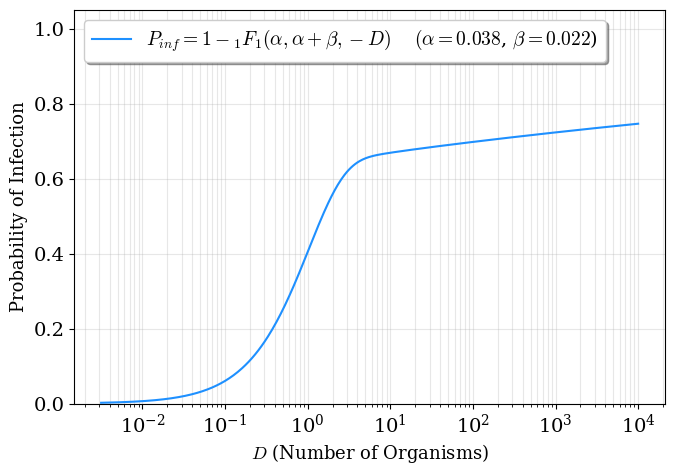

In [16]:
def approximate_beta_poisson(dose, alpha, beta):
    """The standard approximation: 1 - (1 + d/beta)^-alpha"""
    return 1 - (1 + dose / beta)**(-alpha)

def exact_beta_poisson(dose, alpha, beta):
    """The exact form: 1 - 1F1(alpha, alpha+beta, -dose)"""
    return 1 - hyp1f1(alpha, alpha + beta, -dose)

# --- Parameters ---
# Old parameters (Approximate model usually used with these)
old_alpha, old_beta = 0.145, 7.59

# New parameters (Teunis et al. 2018 - Exact model)
new_alpha, new_beta = 0.038, 0.022

# Generate dose range (log space)
doses = np.logspace(-2.5, 4, 500)

# Calculate probabilities
prob_old = approximate_beta_poisson(doses, old_alpha, old_beta)
prob_new = exact_beta_poisson(doses, new_alpha, new_beta)

# --- Plotting ---
plt.figure(figsize=(7, 5))

# Formula strings in LaTeX
# r'' indicates a raw string, required for LaTeX backslashes in matplotlib
# old_formula = r'$P(d) = 1 - (1 + \frac{d}{\beta})^{-\alpha}$'
new_formula = r'$P_{inf} = 1 - {}_1F_1(\alpha, \alpha + \beta, -D)$'

# plt.plot(doses, prob_old, 
#          label=fr'Old Model: {old_formula} $\quad\quad\quad\quad\quad\quad(\alpha={old_alpha}, \beta={old_beta}$)', 
#          linestyle='--', color='red', lw=2.5)

plt.plot(doses, prob_new, 
         label=fr'{new_formula} $\quad(\alpha={new_alpha}$, $\beta={new_beta}$)', 
         color='dodgerblue', lw=1.5)

# Formatting
plt.xscale('log')
plt.xlabel(r'$D$ (Number of Organisms)', fontsize=13)
plt.ylabel('Probability of Infection', fontsize=13)

# Grid and Legend
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(fontsize=14, loc='upper left', frameon=True, shadow=True)
plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig("campylobacter_dose_response.pdf", bbox_inches="tight")
plt.show()

/var/folders/mz/n_rzzjx149d19ncnxglpf7n40000gn/T/ipykernel_42339/2342523534.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


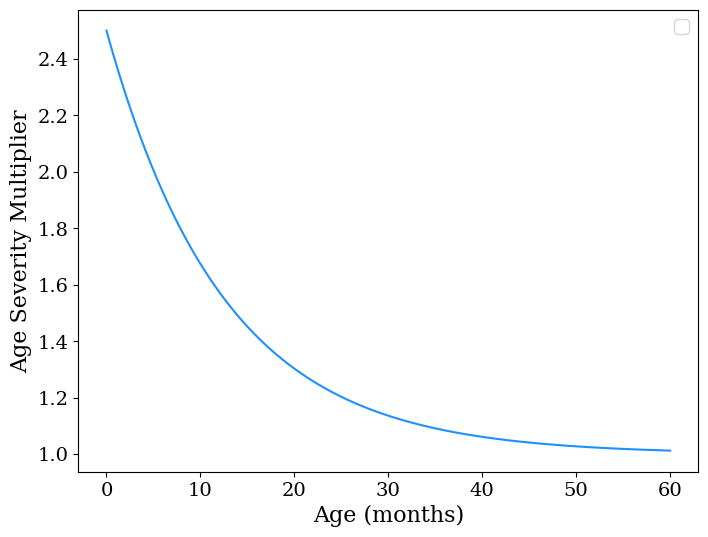

In [8]:
N = 300
months = np.linspace(0, 60, N)

months = torch.Tensor(months)
severity = []

plt.plot(
    months, _get_age_effect(months, torch.ones(N, dtype=torch.bool)),
    color="dodgerblue"
)

plt.xlabel("Age (months)")
plt.ylabel("Age Severity Multiplier")
plt.legend()
plt.show()

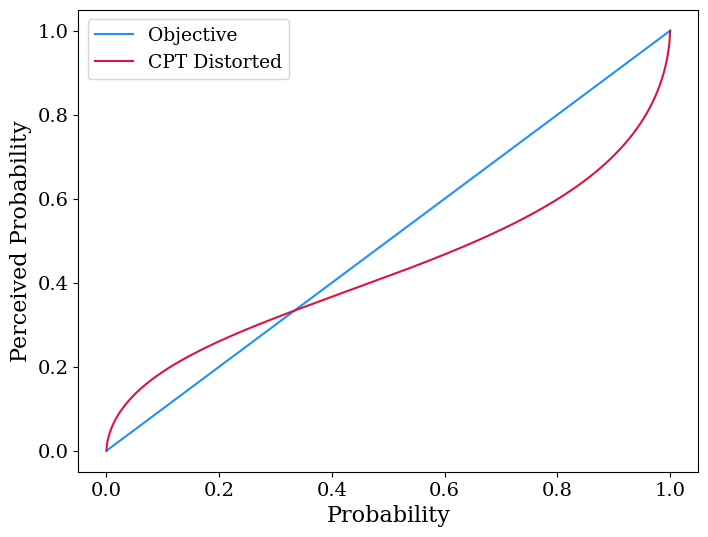

In [14]:
p = np.linspace(0, 1, 1000)
plt.plot(p, p, label="Objective", color="dodgerblue")
plt.plot(p, probability_weighting(p, gamma=0.6), label="CPT Distorted", color="crimson")
plt.legend()
plt.xlabel("Probability")
plt.ylabel("Perceived Probability")
plt.savefig("probability-distortion.pdf", bbox_inches="tight")
plt.show()